# EDA

## Importing Libraries

In [ ]:
# Importing necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Loading Data

In [5]:
# Loading in the cleaned dataset
df = pd.read_csv(
    "C:/Users/sKALa/Repos/Semester 2/Data Visualisation and Insight/CAs/CA 2/Data-Visualisation-and-Insight---CA-2/data/preprocessed/cleanData.csv")

# For some reason I have to repeat the conversion, it probably doesn't work between notebooks
df["activityDate"] = pd.to_datetime(df["activityDate"])

display(df.head())

,ID,activityDate,totalSteps,totalDistance,trackerDistance,loggedActivitiesDistance,veryActiveDistance,moderatelyActiveDistance,lightActiveDistance,sedentaryActiveDistance,...,month,activeMinutes,totalRecordedMinutes,activeHours,sedentaryHours,activePercentage,caloriesPerStep,caloriesPerDistance,stepCategory,dayType
0,1503960366,2016-03-25,11004,7.11,7.11,0.0,2.57,0.46,4.07,0.0,...,March,250,1054,4.166667,13.400000,23.719165,0.165304,255.836845,Highly active,Weekday
1,1503960366,2016-03-26,17609,11.55,11.55,0.0,6.92,0.73,3.91,0.0,...,March,380,968,6.333333,9.800000,39.256198,0.122324,186.493503,Highly active,Weekend
2,1503960366,2016-03-27,12736,8.53,8.53,0.0,4.66,0.16,3.71,0.0,...,March,329,934,5.483333,10.083333,35.224839,0.152638,227.901531,Highly active,Weekend
3,1503960366,2016-03-28,13231,8.93,8.93,0.0,3.19,0.79,4.95,0.0,...,March,283,1363,4.716667,18.000000,20.763023,0.146021,216.349377,Highly active,Weekday
4,1503960366,2016-03-29,12041,7.85,7.85,0.0,2.16,1.09,4.61,0.0,...,March,299,1062,4.983333,12.716667,28.154426,0.156632,240.254780,Highly active,Weekday


In [6]:
# Checking the dataset
print("Rows and columns:")
print(df.shape)

print("\nColumn names:")
print(df.columns)

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isna().sum())

Rows and columns:
(1373, 26)

Column names:
Index(['ID', 'activityDate', 'totalSteps', 'totalDistance', 'trackerDistance',
       'loggedActivitiesDistance', 'veryActiveDistance',
       'moderatelyActiveDistance', 'lightActiveDistance',
       'sedentaryActiveDistance', 'veryActiveMinutes', 'fairlyActiveMinutes',
       'lightlyActiveMinutes', 'sedentaryMinutes', 'calories', 'weekday',
       'month', 'activeMinutes', 'totalRecordedMinutes', 'activeHours',
       'sedentaryHours', 'activePercentage', 'caloriesPerStep',
       'caloriesPerDistance', 'stepCategory', 'dayType'],
      dtype='object')

Data types:
ID                                   int64
activityDate                datetime64[ns]
totalSteps                           int64
totalDistance                      float64
trackerDistance                    float64
loggedActivitiesDistance           float64
veryActiveDistance                 float64
moderatelyActiveDistance           float64
lightActiveDistance                fl

There are missing values in caloriesPerStep & caloriesPerDistance, although it's just records when that specific user didn't take any steps/walked any distance at that timestamp. I think it's okay to leave them in.

## Basic Summary Statistics

In [8]:
# Summary statistics
df[["totalSteps", "totalDistance", "veryActiveMinutes", "fairlyActiveMinutes", "lightlyActiveMinutes", "sedentaryMinutes",
  "activeMinutes","calories"]].describe()

,totalSteps,totalDistance,veryActiveMinutes,fairlyActiveMinutes,lightlyActiveMinutes,sedentaryMinutes,activeMinutes,calories
count,1373.000000,1373.000000,1373.000000,1373.000000,1373.000000,1373.000000,1373.000000,1373.000000
mean,7247.360524,5.194137,19.551347,13.502549,184.610342,993.426074,217.664239,2264.449381
std,5214.783821,3.988507,31.667869,26.605437,114.289153,314.794986,129.137321,754.164188
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3108.000000,2.140000,0.000000,0.000000,108.000000,729.000000,122.000000,1793.000000
50%,6910.000000,4.900000,2.000000,5.000000,195.000000,1058.000000,241.000000,2114.000000
75%,10538.000000,7.480000,29.000000,18.000000,260.000000,1247.000000,313.000000,2766.000000
max,36019.000000,28.030001,210.000000,660.000000,720.000000,1440.000000,720.000000,4900.000000


In [9]:
# Average daily activity
print("Average daily steps:", round(df["totalSteps"].mean(), 2))
print("Average daily distance:", round(df["totalDistance"].mean(), 2))
print("Average daily calories:", round(df["calories"].mean(), 2))
print("Average active minutes:", round(df["activeMinutes"].mean(), 2))
print("Average sedentary hours:", round(df["sedentaryHours"].mean(), 2))

Average daily steps: 7247.36
Average daily distance: 5.19
Average daily calories: 2264.45
Average active minutes: 217.66
Average sedentary hours: 16.56


**Interpretation:**<br>
- On average, users recorded ~7247 steps and ~5.2km a day, whilst burning ~2264 calories
- On the other hand, the average sedentary hours were ~16.56 per day -> even if active, spent a lot of time sitting during a day

## Average Steps by Weekday

In [11]:
# Average steps by weekday
weekdaySteps = df.groupby("weekday")["totalSteps"].mean().reset_index()

weekdayOrder = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

weekdaySteps["weekday"] = pd.Categorical(weekdaySteps["weekday"], categories = weekdayOrder, ordered = True)
weekdaySteps = weekdaySteps.sort_values("weekday")

display(weekdaySteps)

,weekday,totalSteps
1,Monday,7541.319149
5,Tuesday,6830.850746
6,Wednesday,7547.575758
4,Thursday,7268.297436
0,Friday,7187.532663
2,Saturday,7752.271357
3,Sunday,6606.725389


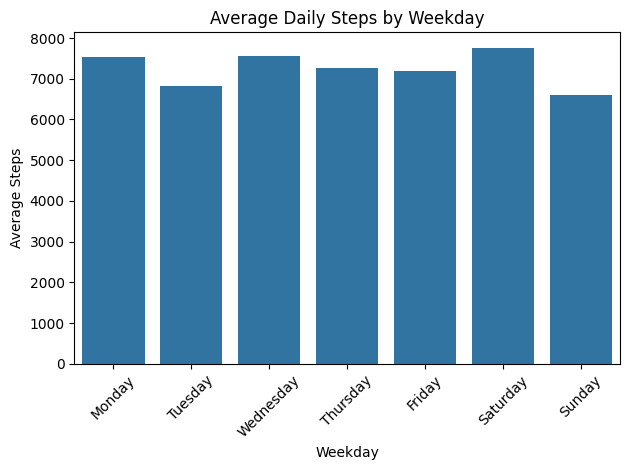

In [12]:
# Plot
plt.figure()
sns.barplot(data = weekdaySteps, x = "weekday", y="totalSteps")
plt.title("Average Daily Steps by Weekday")
plt.xlabel("Weekday")
plt.ylabel("Average Steps")
plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()

**Interpretation:**<br>
- Highest average on Saturday -> weekend, more free time
- Lowest average on Sunday -> generally considered a "rest day"<br>

Generally, not that much of a difference between weekdays.

## Daily Steps Over Time

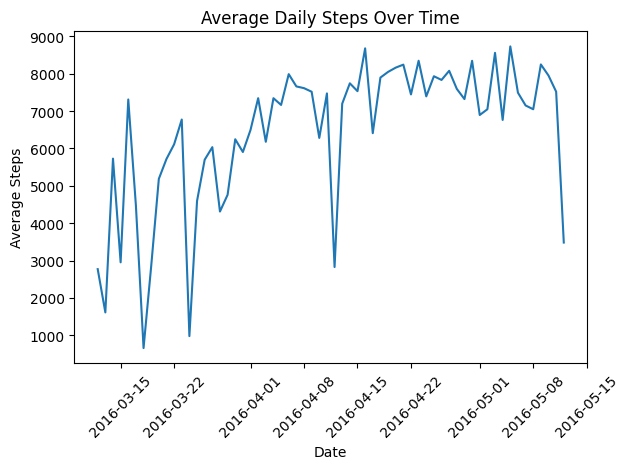

In [14]:
# Daily steps over time
dailySteps = df.groupby("activityDate")["totalSteps"].mean().reset_index()

# Plot
plt.figure()
sns.lineplot(data = dailySteps, x = "activityDate", y = "totalSteps")
plt.title("Average Daily Steps Over Time")
plt.xlabel("Date")
plt.ylabel("Average Steps")
plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()

**Interpretation:**<br>
- noticeable dips around St. Patrick's Day & Easter 2016 -> it might be a possible cause

## Calories vs Steps by Step Category

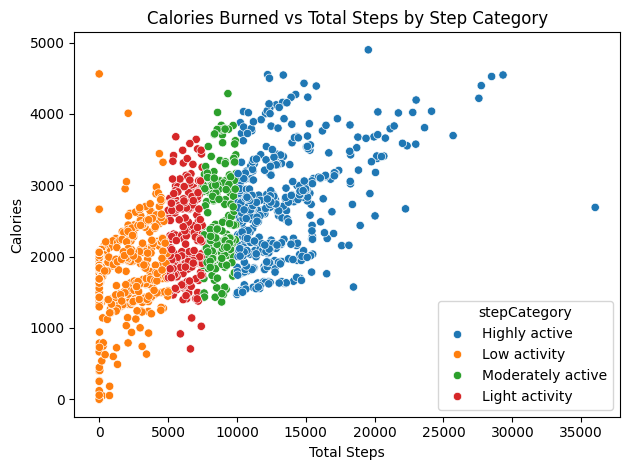

In [16]:
# Calories vs steps by step category
plt.figure()
sns.scatterplot(data = df, x = "totalSteps", y = "calories", hue = "stepCategory")
plt.title("Calories Burned vs Total Steps by Step Category")
plt.xlabel("Total Steps")
plt.ylabel("Calories")
plt.tight_layout()
plt.show()

**Interpretation:**<br>
- more steps generally mean more calories burned
- there is still variation though, as it's not always the case -> might be caused by body characteristics, activity intensity, etc.

## Calories vs Distance

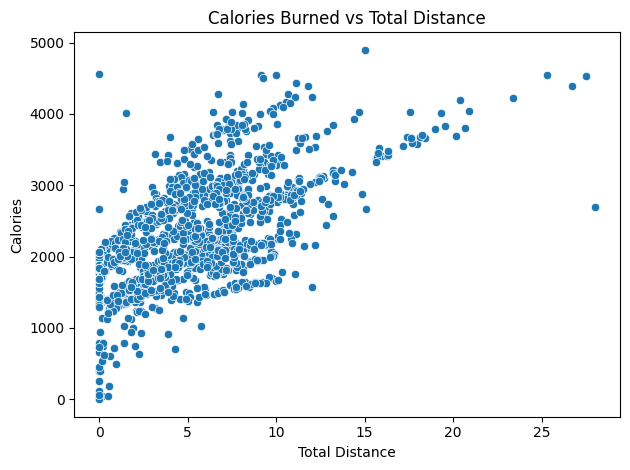

In [17]:
# Calories vs distance
plt.figure()
sns.scatterplot(data = df, x = "totalDistance", y = "calories")
plt.title("Calories Burned vs Total Distance")
plt.xlabel("Total Distance")
plt.ylabel("Calories")
plt.tight_layout()
plt.show()

**Interpretation:**<br>
- Quite similar to the previous one

## Calories vs Active Minutes

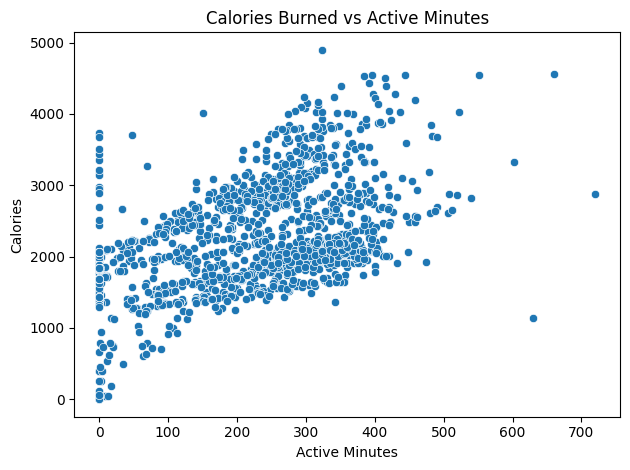

In [18]:
# Calories vs active minutes
plt.figure()
sns.scatterplot(data = df, x = "activeMinutes", y = "calories")
plt.title("Calories Burned vs Active Minutes")
plt.xlabel("Active Minutes")
plt.ylabel("Calories")
plt.tight_layout()
plt.show()

**Interpretation:**<br>
- Same again, similar results

## Activity Minutes Breakdown

In [19]:
# Activity minutes breakdown
activityMinutes = df[["veryActiveMinutes", "fairlyActiveMinutes", "lightlyActiveMinutes", "sedentaryMinutes"]].mean().reset_index()

activityMinutes.columns = ["activityType", "averageMinutes"]

display(activityMinutes)

,activityType,averageMinutes
0,veryActiveMinutes,19.551347
1,fairlyActiveMinutes,13.502549
2,lightlyActiveMinutes,184.610342
3,sedentaryMinutes,993.426074


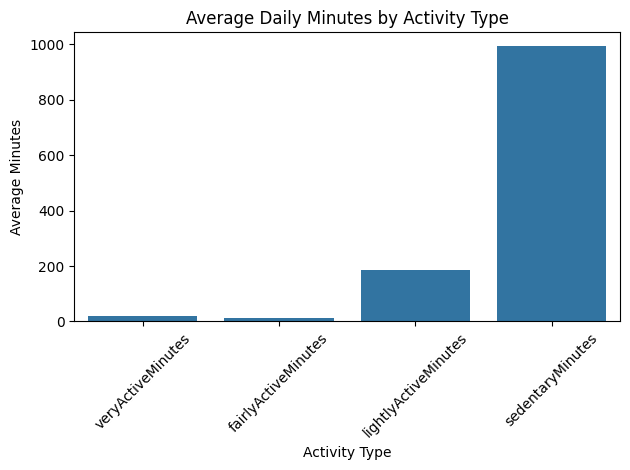

In [20]:
# Plot
plt.figure()
sns.barplot(data = activityMinutes, x = "activityType", y = "averageMinutes")
plt.title("Average Daily Minutes by Activity Type")
plt.xlabel("Activity Type")
plt.ylabel("Average Minutes")
plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()

**Interpretation:**<br>
- sedentary time is way higher than the rest in an average day

## Correlation Heatmap

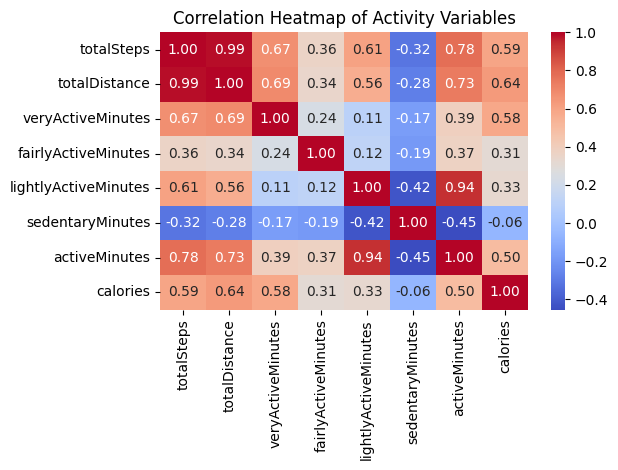

In [21]:
# Correlation heatmap
correlationColumns = ["totalSteps", "totalDistance", "veryActiveMinutes", "fairlyActiveMinutes", "lightlyActiveMinutes", "sedentaryMinutes",
                     "activeMinutes", "calories"]

correlation = df[correlationColumns].corr()

# Plot
plt.figure()
sns.heatmap(correlation, annot = True, cmap = "coolwarm", fmt = ".2f")
plt.title("Correlation Heatmap of Activity Variables")
plt.tight_layout()
plt.show()

**Interpretation:**<br>
- sedentary minutes has negative correlation with every other variable
- calories has moderately strong positive relationships with total steps, total distance and very active minutes

## User Summary

In [23]:
# General user summary
userSummary = df.groupby("ID").agg({"totalSteps":"mean", "totalDistance":"mean", "veryActiveMinutes":"mean", "fairlyActiveMinutes":"mean",
                                  "lightlyActiveMinutes":"mean", "sedentaryMinutes":"mean", "activeMinutes":"mean", "calories":"mean"}).reset_index()

display(userSummary.head())

,ID,totalSteps,totalDistance,veryActiveMinutes,fairlyActiveMinutes,lightlyActiveMinutes,sedentaryMinutes,activeMinutes,calories
0,1503960366,11910.755102,7.717143,37.877551,18.000000,220.938776,835.755102,276.816327,1805.142857
1,1624580081,5106.061224,3.433469,5.775510,3.897959,141.061224,1264.979592,150.734694,1433.816327
2,1644430081,7780.925000,5.658750,10.875000,26.900000,190.775000,1129.950000,228.550000,2837.575000
3,1844505072,2785.047619,1.841429,0.309524,1.166667,122.428571,1160.190476,123.904762,1574.738095
4,1927972279,1283.142857,0.888810,0.976190,1.047619,59.071429,1227.166667,61.095238,2194.880952


In [24]:
# Most active users
userSummary.sort_values("totalSteps", ascending = False).head(10)

,ID,totalSteps,totalDistance,veryActiveMinutes,fairlyActiveMinutes,lightlyActiveMinutes,sedentaryMinutes,activeMinutes,calories
34,8877689391,16263.333333,13.292619,65.833333,11.476190,234.666667,1095.642857,311.976190,3417.166667
29,8053475328,14704.634146,11.437805,84.317073,10.097561,152.560976,1137.902439,246.975610,2925.829268
0,1503960366,11910.755102,7.717143,37.877551,18.000000,220.938776,835.755102,276.816327,1805.142857
5,2022484408,11588.428571,8.275238,37.238095,20.380952,257.142857,1096.190476,314.761905,2502.928571
27,7007744171,11550.297297,8.226757,34.864865,16.486486,277.675676,1038.459459,329.027027,2560.324324
26,6962181067,10690.818182,7.238409,26.181818,21.954545,251.159091,641.454545,299.295455,2015.863636
12,3977333714,10357.268293,7.053902,16.317073,53.512195,185.243902,706.195122,255.073171,1481.390244
8,2347167796,9632.562500,6.413750,12.250000,22.000000,250.875000,676.968750,285.125000,2023.687500
16,4388161847,8595.692308,6.671539,18.410256,16.179487,182.307692,949.000000,216.897436,2829.538462
31,8378563200,8577.285714,6.802143,57.595238,10.166667,159.761905,706.833333,227.523810,3408.880952


In [25]:
# Least active users
userSummary.sort_values("totalSteps").head(10)

,ID,totalSteps,totalDistance,veryActiveMinutes,fairlyActiveMinutes,lightlyActiveMinutes,sedentaryMinutes,activeMinutes,calories
10,2891001357,773.625000,0.603750,0.000000,82.500000,168.750000,1099.875000,251.250000,2273.375000
4,1927972279,1283.142857,0.888810,0.976190,1.047619,59.071429,1227.166667,61.095238,2194.880952
24,6391747486,1336.888889,1.074444,5.111111,0.666667,34.333333,1261.888889,40.111111,1763.111111
14,4057192912,2009.971429,1.482000,1.228571,5.000000,46.628571,1344.314286,52.857143,1900.628571
33,8792009665,2208.325000,1.413500,1.150000,4.550000,103.275000,1016.150000,108.975000,1993.675000
3,1844505072,2785.047619,1.841429,0.309524,1.166667,122.428571,1160.190476,123.904762,1574.738095
25,6775888955,3301.228571,2.372000,13.285714,23.657143,61.714286,1227.028571,98.657143,2284.257143
13,4020332650,3977.354839,2.853065,4.629032,6.387097,100.419355,1166.225806,111.435484,2721.258065
7,2320127002,4122.833333,2.780952,0.952381,2.000000,174.976190,1231.000000,177.928571,1659.761905
23,6290855005,4615.846154,3.490513,4.051282,5.564103,179.205128,1217.794872,188.820513,2488.333333


**Interpretation:**<br>
- Most active user -> ~16000 steps a day
- Least active user -> ~800 steps a day
- There is a huge difference between user activities, so clustering would make sense in the dashboard

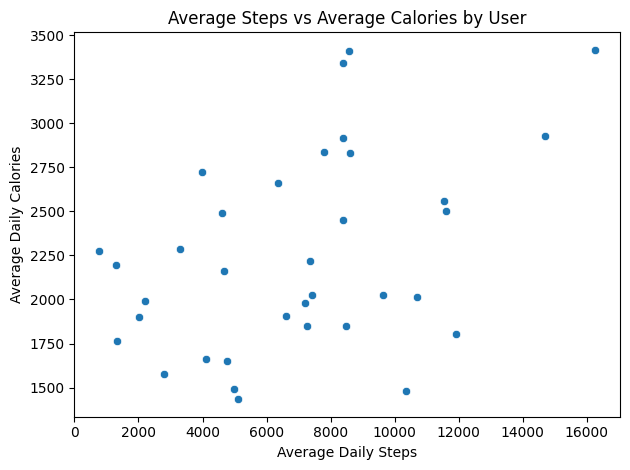

In [26]:
# Average steps vs average calories by user
plt.figure()
sns.scatterplot(data = userSummary, x = "totalSteps", y = "calories")
plt.title("Average Steps vs Average Calories by User")
plt.xlabel("Average Daily Steps")
plt.ylabel("Average Daily Calories")
plt.tight_layout()
plt.show()

**Interpretation:**<br>
- no relationships can be seen